# Metropolis MCMC

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

f = h5py.File("/Users/relativelyquantum/Programmation/Jupyter/Homework1/Galaxy10_DECals.h5", "r")
galaxy = f["images"]
labels = f["ans"][:]
redshifts = f["redshift"][:]

### Write your own basic Metropolis MCMC algorithm (i.e., without using a MCMC software package).
We will closely follow the methods presented in [1]. We will:

1. Select an initial value $\theta_0$

2. Repeat the following algorithm M times:
  - Draw candidate $\theta^*$ from proposal distribution ~ $q(\theta^* | \theta_{i-1})$
  - Compute the ratio $\alpha$ where $\alpha = \frac{g(\theta^*)q( \theta_{i-1}|\theta^*)}{g(\theta _{i-1})q(\theta^* | \theta_{i-1})}$
  - Since we will draw from 2 normales distribution our candidate variables. The compute ratio will take the form :$$\frac{g(\theta^*)}{g(\theta _{i-1})} $$
  - If $\alpha \ge 1$, we will accept the cadidate.  If $0 < \alpha < 1$ we will accept the candidate with probability $\alpha$. Otherwise we will reject it.
My best fit from Homework 1 Question 1 was : 
$$ \boxed{F_{Data} = \alpha F_{Theoric}^\beta}$$


In [2]:
# Constants used in homework 1
luminosity_Milky_way = 5.37*10**36 # This is the luminosity of the Milky way.
hubble_cst = 70 # We will used this value of the Hubble constant. In km/Mpc
c = 300000 # Speed of light. In km/s

def F_theoric(z): # From Homework 1
     return luminosity_Milky_way*(hubble_cst**2)/((4*np.pi *c**2*z**2))
def Model_flux(z,alpha,beta):  # We will fit for alpha and beta
    return alpha*F_theoric(z)**beta
def Model_test(z,alpha,beta):
    return alpha*z+beta


Our log-likelihood is: $$ log \big( \text{Likelihood}\big) =-\frac{1}{2} \sum_i (\alpha F ^\beta_{\text{Theoric}}(x_i)-\text{Data}_i)^2$$

Since we will assume as we did in the first assignement that our $\sigma =1$.

In [3]:
# We will start with a simple function test f(x)= ax+b
theta_0_test =[1,1]
x_test = np.array([1, 2, 3, 6, 10, 12])   # Data Test
y_test = np.array([3, 5, 10, 13, 15, 18])
def log_likelihood_test(theta): 
    alpha, beta = theta[0], theta[1]  
    data = Model_test(x_test, alpha, beta)
    log_likelihood = -0.5 * np.sum((y_test - data)**2) #Calcul the log likelihood
    return log_likelihood

def metropolis_test(M, initial_value,step_size): #  M:= Number of iteration, step_size to determine
    theta = np.zeros((M, 2))      # Will be our accepted cadidate 2D array
    theta[0] = initial_value    # 2D initial value 
    for i in range(1, M):
        candidate = theta[i-1] + np.random.normal(0, step_size, size=2) #We draw candidate from 2 gaussians 
        #new candidate for 2 variables
        log_ratio = log_likelihood_test(candidate) - log_likelihood_test(theta[i-1])
        probability = np.exp(log_ratio) # We get out of the log space

        if probability >= 1: #If the probability is greather then 1, we accept it immediately
            theta[i] = candidate 
        else:
            if np.random.rand() < probability:  # Else we accept it with with probability = e^log_ration
                theta[i] = candidate
            else:
                theta[i] = theta[i-1] # Rejection mean theta dont change
    return theta



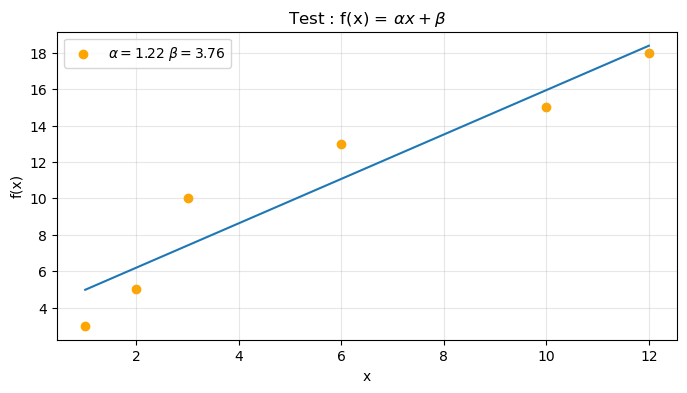

In [4]:

test = metropolis_test(5000,theta_0_test,0.2)
alpha_test_opt = np.mean(test[:, 0]) # Here we choose to take the mean because the model is simple(low iteraion and linear)
beta_test_opt  = np.mean(test[:, 1])

x = np.linspace(-10, 50, 500)
plt.figure(figsize=(8, 4))
plt.scatter(x_test, y_test, color='orange',label=fr'$\alpha = {alpha_test_opt:.2f}\;\beta = {beta_test_opt:.2f}$')
plt.plot(x_test,Model_test(x_test,alpha_test_opt,beta_test_opt))
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Test : f(x) = $\alpha x+\beta$')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

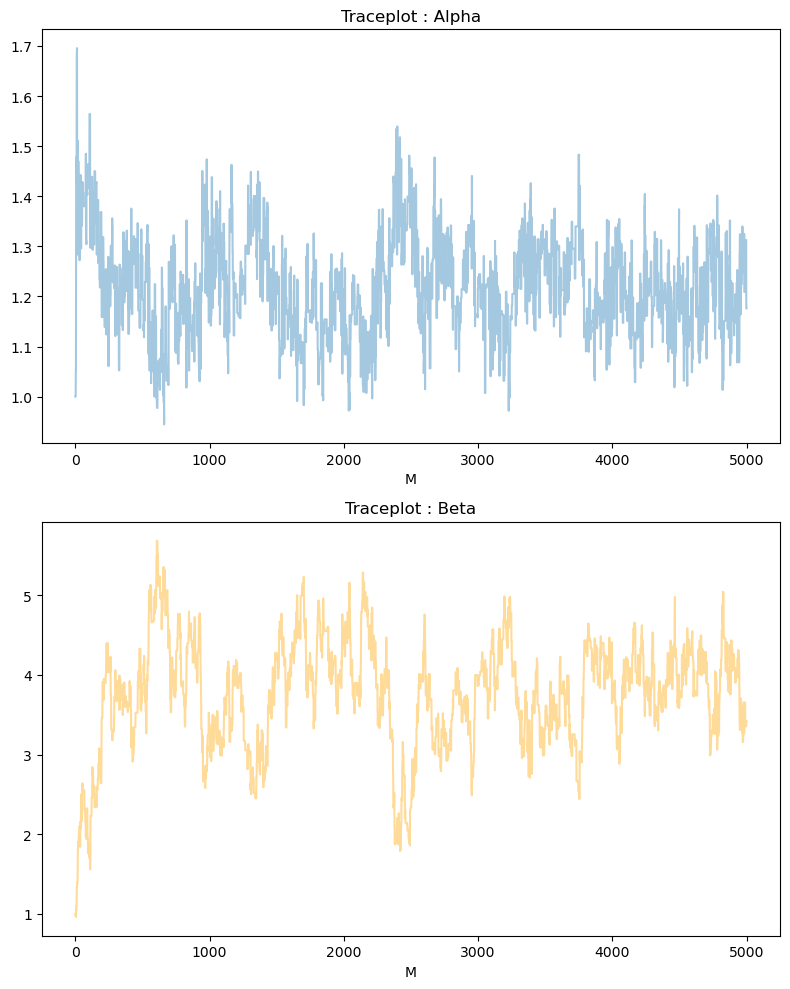

In [5]:
#Trace plot :
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].plot(test[:, 0], alpha=0.4)
axes[0].set_title("Traceplot : Alpha")
axes[0].set_xlabel("M")

axes[1].plot(test[:, 1], color='orange', alpha=0.4)
axes[1].set_title("Traceplot : Beta")
axes[1].set_xlabel("M")

plt.tight_layout()
plt.show()

We are satisfied with this result, as we can see that alpha and beta fluctuate around a certain value. There is no divergence, and we are certain that adding more iterations would not lead us to a more extreme value. We also tried different step sizes 0.1--0.2--0.3, without meaning change in the results.

### Re-perform your best fit from Homework 1 Question 1 using a Bayesian approach with your Metropolis MCMC code, and plot the posteriors (e.g., in a corner plot). Do you get the same result? Discuss the issues you ran into in this endeavour

In [6]:
# The data code from homework 1 :
number_of_galaxy = 300 # We chose to work a restricted number of galaxys/data
idx_class = np.where(labels == 5)[0]  # The class we are working with. 5 is "Barred Spiral Galaxies". 
cut_off = 0.02 
idx_filtered = idx_class[redshifts[idx_class] > cut_off] # We can select a redshift greater then cut_off.
galaxy_data = idx_filtered[:number_of_galaxy]
flux = galaxy[galaxy_data].sum(axis=(1,2,3))  # flux= sum of the pixels in the images 
order = np.argsort(redshifts[galaxy_data])   # We order redshifts to work with as a function

x = redshifts[galaxy_data][order]
y = flux[order]
thet_0 = [10**-25,10**7] # Those are the one we took in homework 1

# We will take the same 2 function we construct in a) and make some change
def log_likelihood(theta): 
    alpha, beta = theta[0], theta[1]  
    data = Model_flux(x, alpha, beta) #We changed the Model
    log_likelihood = -0.5 * np.sum(((y - data))**2)
    return log_likelihood

def metropolis(M, initial_value, step_size):
    theta = np.zeros((M, 2))
    theta[0] = initial_value
    for i in range(1, M):
        candidate = theta[i-1] + np.random.uniform(-step_size, step_size, size=2)
        log_ratio = log_likelihood(candidate) - log_likelihood(theta[i-1])
        probability = np.exp(log_ratio) # We get out of the log space
        if probability >= 1: #If the probability is greather then 1, we accept it
            theta[i] = candidate 
        else:
            if np.random.rand() < probability:  # If not we accept it with  probabili
                theta[i] = candidate
            else:
                theta[i] = theta[i-1] # Rejection means theta dont change
    return theta

In [7]:
homework_1 = metropolis(M=100000, initial_value=np.array([10**4, 0]), step_size=np.array([1000, 0.2]))
alpha_homework1_opt = np.mean(homework_1[:, 0]) # Here we choose to take the mean because the model is simple(low iteraion and linear)
beta_homework1_opt  = np.mean(homework_1[:, 1])
print('alpha:',alpha_homework1_opt, 'beta:',beta_homework1_opt)

/var/folders/ln/0qyrtlln1r14vyg1lhwvgbxc0000gn/T/ipykernel_70614/230365907.py:27: RuntimeWarning: overflow encountered in exp
  probability = np.exp(log_ratio) # We get out of the log space


alpha: 11151.759287219236 beta: 0.09342869586987919


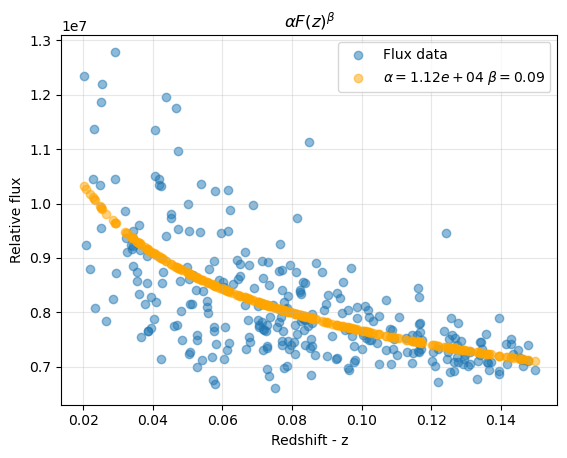

In [8]:
plt.scatter(x,y, alpha=0.5,label = "Flux data ")
plt.scatter(x,Model_flux(x,alpha_homework1_opt,beta_homework1_opt),color='orange',alpha =0.5,label=fr'$\alpha = {alpha_homework1_opt:.2e} \;\beta = {beta_homework1_opt:.2f}$')
plt.xlabel("Redshift - z")
plt.ylabel("Relative flux")
plt.title(fr"$\alpha F(z)^\beta$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()



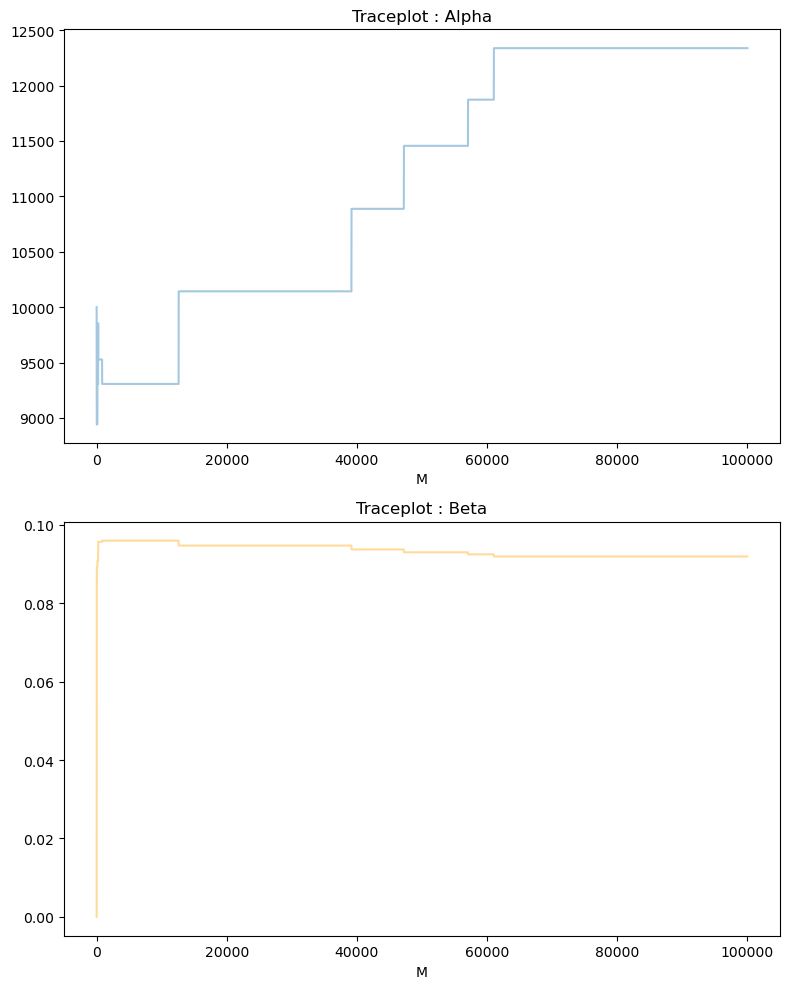

In [9]:
#Trace plot :
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].plot(homework_1[:, 0], alpha=0.4)
axes[0].set_title("Traceplot : Alpha")
axes[0].set_xlabel("M")

axes[1].plot(homework_1[:, 1], color='orange', alpha=0.4)
axes[1].set_title("Traceplot : Beta")
axes[1].set_xlabel("M")

plt.tight_layout()

We find alpha and beta similar, but not exactly the same. Also, their values vary from one simulation to another. Exemple alpha can go from 12917.87 to 12755.85 from one iteration to an other. In our case, this isn't a huge problem, since our model doesn't react strongly to a change in alpha—not as much as it does to a change in beta

The problem is that inour new model, our Metropolis algorithm is extremely sensitive to the initial conditions. Here, they have been chosen to be close to the values of alpha and beta that we used in Assignment 1, and that we know that they are close to their "real" value. But a drastic change in the initial conditions does not give the correct curve. The problem is that the acceptance rate for our new metropolis algorithme is close to 0%. To make the algorithm more efficient, we would need to find a way to modify the concept of the acceptance rate. One reason is that we set $\sigma = 1$ since we don't have a standard error for our data. Changing sigma—for example, to $\sigma = 10,000$ would drastically change our random walk.



## References
1. Machine Learning TV. “Understanding Metropolis-Hastings Algorithm.” YouTube, 12 Feb. 2020, www.youtube.com/watch?v=0lpT-yveuIA